# Italy and its neighbors: France, Swiss and Austria
## Task A: Optimal Generators Capacities

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
import pypsa

## Prerequisites: handling technology data and costs

We maintain a database (https://github.com/PyPSA/technology-data/tree/v0.11.0, v0.11.0) which collects assumptions and projections for energy system technologies (such as costs, efficiencies, lifetimes, etc.) for given years, which we can load into a `pandas.DataFrame`. This requires some pre-processing to load (e.g. converting units, setting defaults, re-arranging dimensions):

In [69]:
year = 2020

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [70]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # already for the CCGT part later

Let's also write a small utility function that calculates the **annuity** to annualise investment costs. The formula is

$$
a(r, n) = \frac{r}{1-(1+r)^{-n}}
$$
where $r$ is the discount rate and $n$ is the lifetime.

In [71]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [72]:
annuity(0.07, 20)

0.09439292574325567

Based on this, we can calculate the marginal generation costs (€/MWh):

In [73]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

and the annualised investment costs (`capital_cost` in PyPSA terms, €/MW/a):

In [74]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [75]:
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

We can now read the capital and marginal cost of onshore wind, solar and OCGT

In [76]:
costs.at["onwind", "capital_cost"] #EUR/MW/a

113584.19278649535

In [77]:
costs.at["solar", "capital_cost"] #EUR/MW/a

75323.80208848667

In [78]:
costs.at["OCGT", "capital_cost"] #EUR/MW/a

49760.036522390714

In [79]:
costs.at["OCGT", "marginal_cost"] #EUR/MWh

66.182

In [80]:
costs.at["CCGT", "marginal_cost"] #EUR/MWh

48.527628571428565

In [81]:
costs.at["CCGT", "capital_cost"] #EUR/MWh

110915.22632898652

## Retrieving time series data

wind data from [https://zenodo.org/record/3253876#.XSiVOEdS8l0](https://zenodo.org/record/3253876#.XSiVOEdS8l0) and solar PV data from [https://zenodo.org/record/2613651#.X0kbhDVS-uV](https://zenodo.org/record/3253876#.XSiVOEdS8l0) is used.

In [82]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We will use timeseries for Italy

In [83]:
country = 'ITA'

### Joint capacity and dispatch optimization

For building the model, we start again by initialising an empty network, adding the snapshots, and the electricity bus.

In [84]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus", "ITA")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [85]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green"],
)

Next, we add the demand time series to the model.

In [86]:
# add load to the bus
n.add("Load",
      "demand",
      bus="ITA",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

<Axes: title={'center': 'Electricity demand in Italy in 2015'}, xlabel='snapshot', ylabel='MW'>

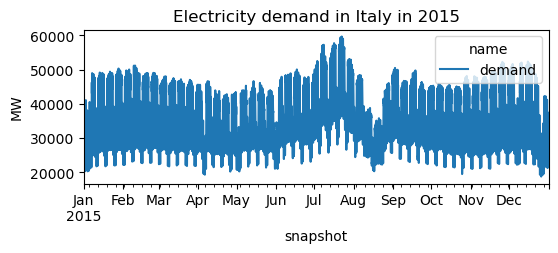

In [87]:
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW", title="Electricity demand in Italy in 2015")

We now add the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [88]:
n.add(
    "Generator",
    "OCGT",
    bus="ITA",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="ITA",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="ITA",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

<Axes: xlabel='snapshot', ylabel='CF'>

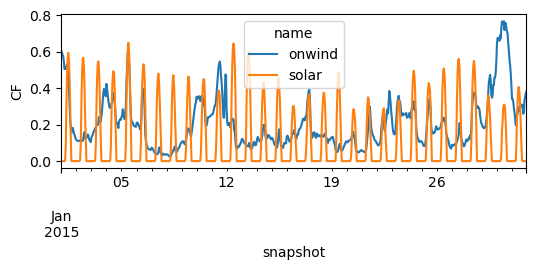

In [89]:
n.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [90]:
n.optimize()

Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 305.94it/s]
INFO:linopy.io: Writing time: 0.2s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-0i_8u3_x has 61323 rows; 26283 cols; 100919 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+04, 6e+04]
Presolving model
26632 rows, 17875 cols, 57820 nonzeros  0s
Dependent equations search running on 4556 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
26632 rows, 17875 cols, 57820 nonzeros  0s
Presolve reductions: rows 26632(-34691); columns 17875(-8408); nonzeros 57820(-43099) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 2.27e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      18196     2.2670381414e+10 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-0i_8u3_x
Model status        : Optimal
Simplex   iterations: 18196
Objective value     :  2.2670381414e+10
P-D objective error :  1.5144110178e-15
HiGHS run time      :          0.52


('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [91]:
n.objective / 1e9

22.670381413833148

The optimised capacities in GW:

In [92]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT      52.558000
onwind    -0.000000
solar     66.122671
Name: p_nom_opt, dtype: float64

The total energy generation by technology in TWh:

In [93]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT      227.759279
onwind      0.000000
solar      86.585790
dtype: float64

We can plot the dispatch of every generator thoughout January

<Axes: xlabel='snapshot', ylabel='dispatch'>

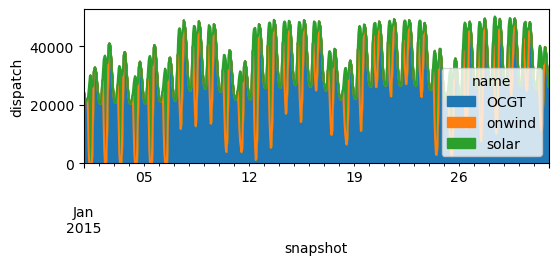

In [94]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(6, 2), ylabel="dispatch")

<Axes: xlabel='snapshot', ylabel='demand'>

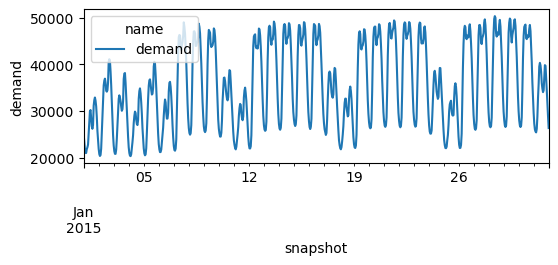

In [95]:
n.loads_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="demand")

**b) Calculate the revenues collected by every technology throughout the year and show that their sum is equal to their costs.**

To calculate the revenues collected by every technology, we multiply the energy generated in every hour by the electricity price in that hour and sum for the entire year.

In [96]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT      17688.852635
onwind        0.000000
solar      4981.528779
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [97]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  OCGT       17688.852635
           solar       4981.528779
dtype: float64

**Now we are adding the possibility of installing battery storage. The annualised capital cost of the battery comprises 12,894 EUR/MWh/a for the energy capacity and 24,678 EUR/MW/a for the inverter. The inverter efficiency is 0.96 and the battery is assumed to have a fixed energy-to-power ratio of 2 hours. Assume also an existing combined-cycle gas turbine (CCGT) unit with an electricity generation capacity of 6 GW and efficiency of 0.58. The annualised capital cost and marginal generation costs for the CCGT are respectively 104,788 EUR/MW/a and 46.8 EUR/MWh.**

Let's build the model from scratch to include the battery storage and the CCGT generator.

In [98]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus",
            "ITA")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

We add all the technologies we are going to include as carriers. Defining carriers is not mandatory but will ease plotting and assigning emissions of CO2 in future steps. 

In [99]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
    "battery storage",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green", "brown"],

)

Next, we add the demand time series to the model.

In [100]:
# add load to the bus
n.add("Load",
      "demand",
      bus="ITA",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

<Axes: xlabel='snapshot', ylabel='MW'>

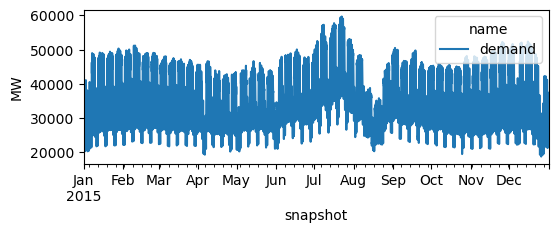

In [101]:
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

We add now the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [102]:
n.add(
    "Generator",
    "OCGT",
    bus="ITA",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="ITA",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="ITA",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

<Axes: xlabel='snapshot', ylabel='CF'>

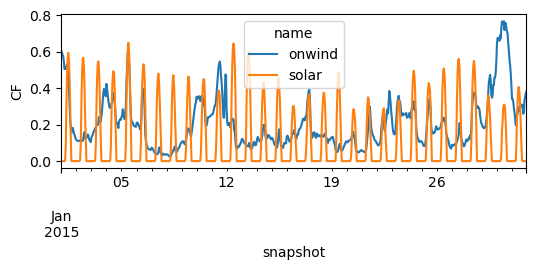

In [103]:
n.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

We add the battery storage, assuming a fixed energy-to-power ratio of 2 hours, i.e. if fully charged, the battery can discharge at full capacity for 2 hours. 

For the capital cost, we have to factor in both the capacity and energy cost of the storage. 

We include the charging and discharging efficiencies we enforce a cyclic state-of-charge condition, i.e. the state of charge at the beginning of the optimisation period must equal the final state of charge.

We add the Combined Cycle Gas Turbine (CCGT). In this case, its capacity is not extendable but fixed to 1 GW. 

In [104]:
n.add(
    "Generator",
    "CCGT",
    bus="ITA",
    carrier="CCGT",
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom=6000, #6 Gw
)

### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [105]:
n.optimize() # solver_name="highs"

Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 334.78it/s]
INFO:linopy.io: Writing time: 0.11s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-frs8ad52 has 78843 rows; 35043 cols; 127199 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 6e+04]
Presolving model
30836 rows, 30839 cols, 74988 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
30836 rows, 30839 cols, 74988 nonzeros  0s
Presolve reductions: rows 30836(-48007); columns 30839(-4204); nonzeros 74988(-52211) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.14345e+08) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35043 primals, 78843 duals
Objective: 2.15e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      22568     2.1495305448e+10 Pr: 0(0) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-frs8ad52
Model status        : Optimal
Simplex   iterations: 22568
Objective value     :  2.1495305448e+10
P-D objective error :  2.6921672575e-13
HiGHS run time      :          0.61


('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [106]:
n.objective / 1e9

21.4953054480545

The optimised capacities in GW:

In [107]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT      46.55800
onwind    -0.00000
solar     62.26094
CCGT       6.00000
Name: p_nom_opt, dtype: float64

The optimised battery capacity can be calcualted as 

In [108]:
n.storage_units.p_nom_opt.div(1e3)  # MW -> GW

Series([], Name: p_nom_opt, dtype: float64)

The total energy generation by technology in TWh:

In [109]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT      182.231579
onwind      0.000000
solar      82.089895
CCGT       50.023595
dtype: float64

We can plot the dispatch of every generator thoughout January

<Axes: xlabel='snapshot', ylabel='dispatch'>

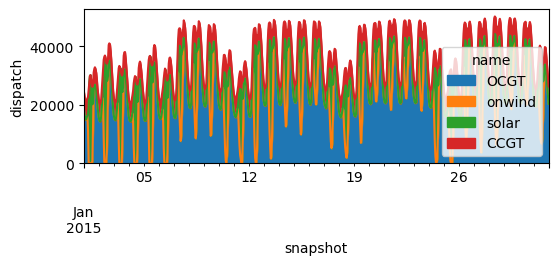

In [110]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(6, 2), ylabel="dispatch")

and the demand time series

<Axes: xlabel='snapshot', ylabel='demand'>

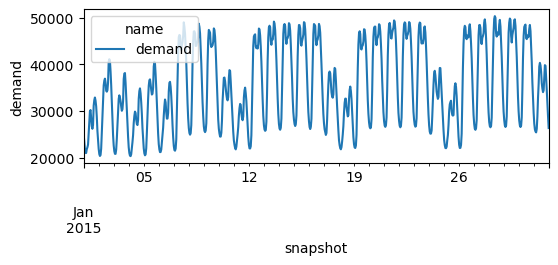

In [111]:
n.loads_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="demand")

**d) How does the CCGT power plant recover its cost?**

To calculate the revenues collected by every technology, for every generator, we multiply the energy generated in very hour by the electricity price in that hour and sum for the entire year.

In [112]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT      14377.178147
onwind        0.000000
solar      4690.600878
CCGT       3587.670025
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [113]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  CCGT        3093.017781
           OCGT       14377.178147
           solar       4690.600878
dtype: float64

The CCGT does not recover its full cost. This is to be expected because its capacity was not optimized but set exogenously 

The battery capacity is also co-optimized with the dispatch, so it exactly recovers its cost by buying electricity when the price is low and selling when it is high. The revenues from market can be calculated by multiplying the battery charging and discharging by the electricity price time series

In [114]:
n.storage_units_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

Series([], dtype: float64)

The market revenues exactly correspons with the total battery costs

In [115]:
n.storage_units.p_nom_opt*(costs.at["battery inverter", "capital_cost"]+ 2 * costs.at["battery storage", "capital_cost"])/(1e6)# EUR -> MEUR

Series([], Name: p_nom_opt, dtype: float64)

## Task C: adding a storage system

In [116]:
# n.add(
#     "StorageUnit",
#     "battery storage",
#     bus="ITA",
#     carrier="battery storage",
#     max_hours=2,
#     capital_cost=costs.at["battery inverter", "capital_cost"]
#     + 2 * costs.at["battery storage", "capital_cost"],
#     efficiency_store=costs.at["battery inverter", "efficiency"],
#     efficiency_dispatch=costs.at["battery inverter", "efficiency"],
#     p_nom_extendable=True,
#     cyclic_state_of_charge=True,
# )

In [117]:
# plot the charging and discharging of the battery
# n.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### C.1 — Model with Battery Storage + CCGT

- **Battery storage** (extendable): max_hours=2, capital cost = battery inverter + 2×battery storage energy cost, round-trip efficiency = 0.96²
- **CCGT** (fixed at 6 GW): existing thermal backup
- **OCGT, onshore wind, solar** (all extendable)


In [118]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Load cost database ────────────────────────────────────────────────────────
year = 2020
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {"FOM": 0, "VOM": 0, "efficiency": 1, "fuel": 0,
            "investment": 0, "lifetime": 25, "discount rate": 0.07}
costs = costs.value.unstack().fillna(defaults)
costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

annuity_factor = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (annuity_factor + costs["FOM"] / 100) * costs["investment"]


In [119]:
# ── Load time series ──────────────────────────────────────────────────────────
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

country = 'ITA'


In [120]:
# ── Build network ─────────────────────────────────────────────────────────────
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z', '2015-12-31 23:00Z', freq='h')
n.set_snapshots(hours_in_2015.values)
n.add("Bus", "ITA")

carriers = ["onwind", "solar", "OCGT", "CCGT", "battery storage"]
colors   = ["dodgerblue", "gold", "indianred", "yellowgreen", "slategray"]
n.add("Carrier", carriers, color=colors)

# Demand
n.add("Load", "demand", bus="ITA", p_set=data_el[country].values)

# Generators
n.add("Generator", "OCGT", bus="ITA", carrier="OCGT",
      capital_cost=costs.at["OCGT", "capital_cost"],
      marginal_cost=costs.at["OCGT", "marginal_cost"],
      efficiency=costs.at["OCGT", "efficiency"],
      p_nom_extendable=True)

fmt = lambda h: h.strftime("%Y-%m-%dT%H:%M:%SZ")
CF_wind  = data_wind[country][[fmt(h) for h in n.snapshots]]
CF_solar = data_solar[country][[fmt(h) for h in n.snapshots]]

n.add("Generator", "onwind", bus="ITA", carrier="onwind",
      p_max_pu=CF_wind.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      efficiency=costs.at["onwind", "efficiency"],
      p_nom_extendable=True)

n.add("Generator", "solar", bus="ITA", carrier="solar",
      p_max_pu=CF_solar.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      efficiency=costs.at["solar", "efficiency"],
      p_nom_extendable=True)

n.add("Generator", "CCGT", bus="ITA", carrier="CCGT",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom=6000)   # fixed 6 GW

# Battery storage — max_hours=2 means energy capacity = 2 × power capacity
bat_cap_cost = (costs.at["battery inverter", "capital_cost"]
                + 2 * costs.at["battery storage", "capital_cost"])
eta = costs.at["battery inverter", "efficiency"]   # one-way efficiency

n.add("StorageUnit", "battery storage", bus="ITA", carrier="battery storage",
      max_hours=2,
      capital_cost=bat_cap_cost,
      efficiency_store=eta,
      efficiency_dispatch=eta,
      p_nom_extendable=True,
      cyclic_state_of_charge=True)

print("Model built. Storage capital cost: {:.0f} EUR/MW/a".format(bat_cap_cost))
print("Battery one-way efficiency: {:.2f}  (round-trip: {:.3f})".format(eta, eta**2))


Model built. Storage capital cost: 87600 EUR/MW/a
Battery one-way efficiency: 0.95  (round-trip: 0.902)


### C.2 — Solve

In [121]:
n.optimize(solver_name="highs")
print("Objective (B€/a):", round(n.objective / 1e9, 3))


Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 380.98it/s]
INFO:linopy.io: Writing time: 0.22s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-oe_feq1g has 140164 rows; 61324 cols; 258600 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 2e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 6e+04]
Presolving model
65876 rows, 57120 cols, 180108 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
65876 rows, 57120 cols, 180108 nonzeros  0s
Presolve reductions: rows 65876(-74288); columns 57120(-4204); nonzeros 180108(-78492) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.14345e+08) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61324 primals, 140164 duals
Objective: 2.15e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      43151     2.1495305448e+10 Pr: 0(0); Du: 0(3.76489e-11) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-oe_feq1g
Model status        : Optimal
Simplex   iterations: 43151
Objective value     :  2.1495305448e+10
P-D objective error :  2.6921672575e-13
HiGHS run time      :          1.50
Objective (B€/a): 21.495


### C.3 — Optimal capacity and generation mix

In [122]:
# Generators
gen_cap = n.generators.p_nom_opt.copy()
gen_cap.loc["CCGT"] = n.generators.loc["CCGT", "p_nom"]  # fixed
bat_cap = n.storage_units.p_nom_opt

print("=== Optimal capacities (GW) ===")
print(gen_cap.div(1e3).rename(lambda x: x).to_string())
print("battery storage: {:.2f} GW  ({:.2f} GWh)".format(
    bat_cap["battery storage"] / 1e3,
    bat_cap["battery storage"] * 2 / 1e3))

print("\n=== Annual generation (TWh) ===")
gen_energy = n.generators_t.p.sum().div(1e6)
bat_discharge = n.storage_units_t.p.clip(lower=0).sum().div(1e6)
print(gen_energy.to_string())
print("battery (discharge): {:.2f} TWh".format(bat_discharge["battery storage"]))

total_demand = n.loads_t.p_set.sum().values[0] / 1e6
print("\nTotal demand: {:.2f} TWh".format(total_demand))


=== Optimal capacities (GW) ===
name
OCGT      46.55800
onwind    -0.00000
solar     62.26094
CCGT       6.00000
battery storage: -0.00 GW  (-0.00 GWh)

=== Annual generation (TWh) ===
name
OCGT      182.231579
onwind      0.000000
solar      82.089895
CCGT       50.023595
battery (discharge): 0.00 TWh

Total demand: 314.35 TWh


### C.4 — Annual electricity mix

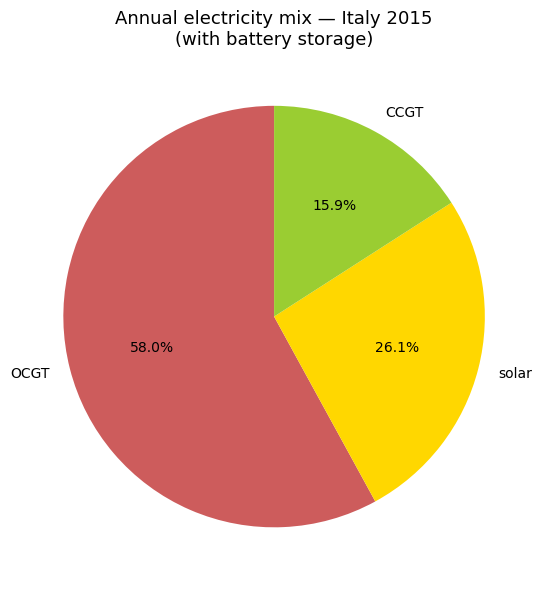

In [123]:
fig, ax = plt.subplots(figsize=(6, 6))
mix = pd.concat([gen_energy, bat_discharge.rename({"battery storage": "battery (discharge)"})])
mix = mix[mix > 0.01]
carrier_colors = dict(zip(
    ["OCGT", "onwind", "solar", "CCGT", "battery (discharge)"],
    ["indianred", "dodgerblue", "gold", "yellowgreen", "slategray"]
))
colors_pie = [carrier_colors.get(t, "gray") for t in mix.index]

wedges, texts, autotexts = ax.pie(
    mix, labels=mix.index, autopct="%1.1f%%",
    colors=colors_pie, startangle=90)
ax.set_title("Annual electricity mix — Italy 2015\n(with battery storage)", fontsize=13)
plt.tight_layout()
plt.savefig("taskC_annual_mix.png", dpi=150)
plt.show()


### C.5 — Time series for summer and winter

/var/folders/4m/0vxd6phj50l_7jlbj12csnd40000gn/T/ipykernel_11918/3745138716.py:19: FutureWarning:

'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.



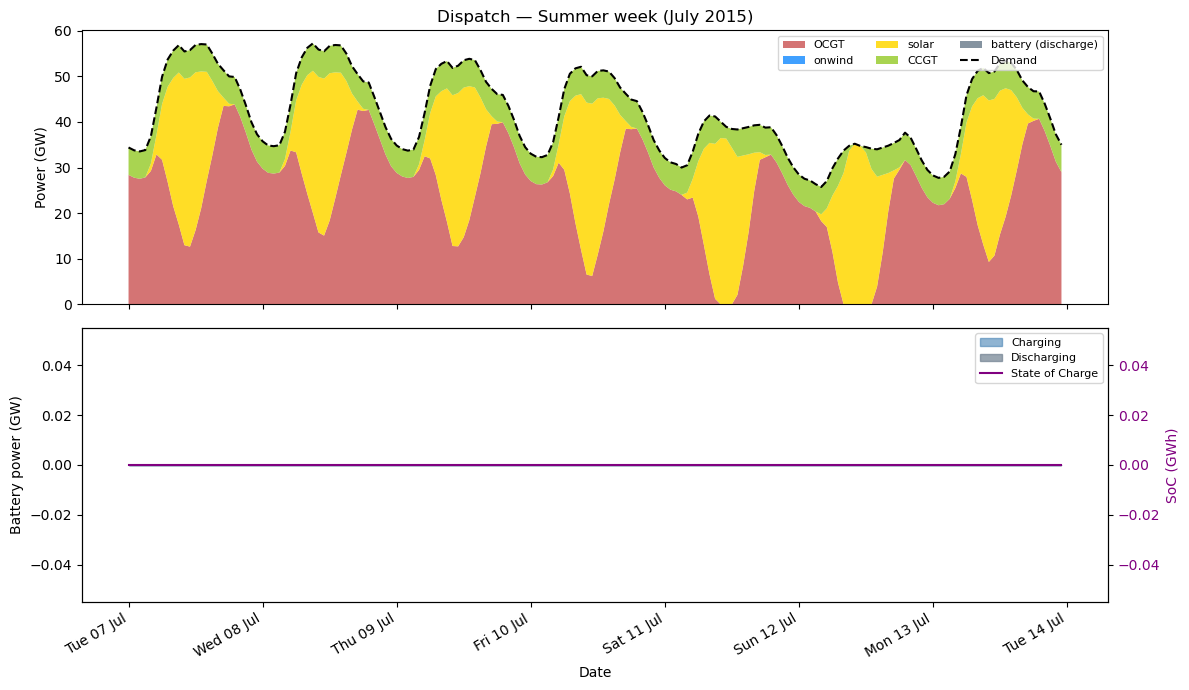

/var/folders/4m/0vxd6phj50l_7jlbj12csnd40000gn/T/ipykernel_11918/3745138716.py:19: FutureWarning:

'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.



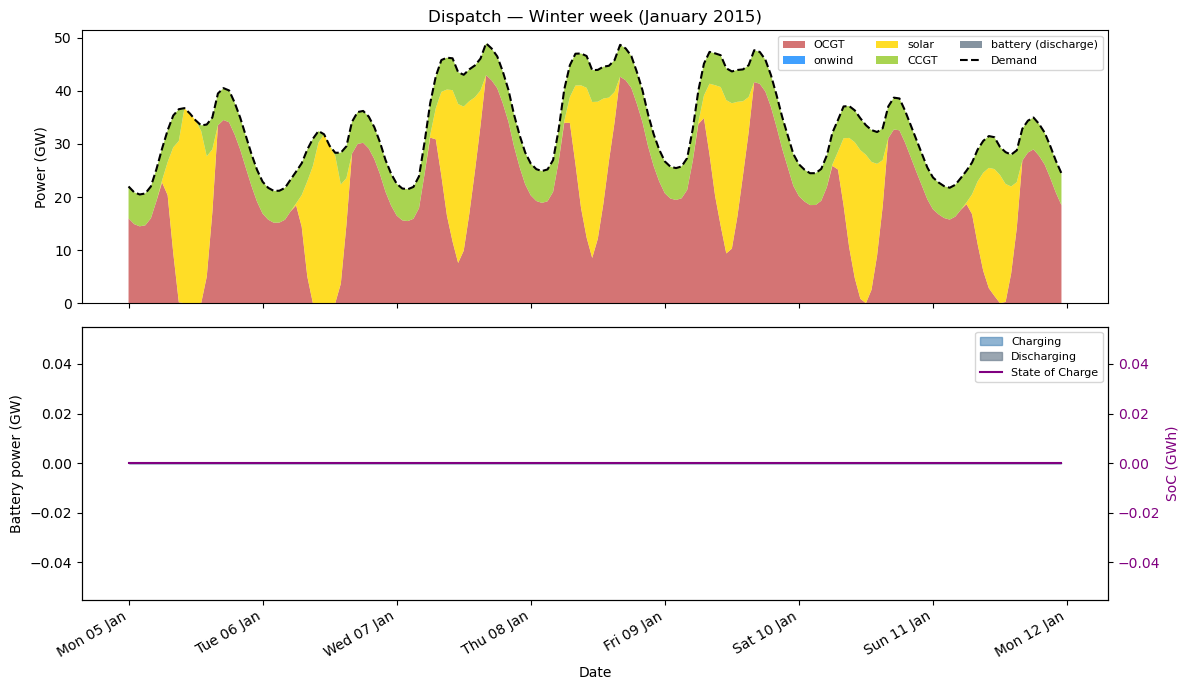

In [124]:
def strip_tz(s):
    """Strip timezone from a Series or DataFrame index (in-place copy)."""
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s = s.copy()
        s.index = s.index.tz_convert(None)
    return s

def plot_dispatch_week(network, start, title, fname):
    """Plot stacked generator dispatch + battery + demand for one week."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # Strip tz from all time-indexed results so slicing and plotting work reliably
    gen_p_all  = strip_tz(network.generators_t.p)
    bat_p_all  = strip_tz(network.storage_units_t.p["battery storage"])
    soc_all    = strip_tz(network.storage_units_t.state_of_charge["battery storage"])
    demand_all = strip_tz(network.loads_t.p["demand"])

    t0 = pd.Timestamp(start)
    t1 = t0 + pd.Timedelta("6D 23H")

    gen_p  = gen_p_all.loc[t0:t1]
    bat_p  = bat_p_all.loc[t0:t1]
    soc    = soc_all.loc[t0:t1]
    demand = demand_all.loc[t0:t1]

    bat_charge    = bat_p.clip(upper=0).abs()
    bat_discharge = bat_p.clip(lower=0)

    plot_df = gen_p.copy()
    plot_df["battery (discharge)"] = bat_discharge
    color_map = {"OCGT": "indianred", "onwind": "dodgerblue",
                 "solar": "gold", "CCGT": "yellowgreen",
                 "battery (discharge)": "slategray"}
    colors_area = [color_map.get(c, "gray") for c in plot_df.columns]

    axes[0].stackplot(plot_df.index, plot_df.T / 1e3,
                      labels=plot_df.columns, colors=colors_area, alpha=0.85)
    axes[0].plot(demand.index, demand.values / 1e3, "k--", lw=1.5, label="Demand")
    axes[0].set_ylabel("Power (GW)")
    axes[0].legend(loc="upper right", fontsize=8, ncol=3)
    axes[0].set_title(title)

    axes[1].fill_between(bat_charge.index, -bat_charge.values / 1e3, 0,
                         color="steelblue", alpha=0.6, label="Charging")
    axes[1].fill_between(bat_discharge.index, 0, bat_discharge.values / 1e3,
                         color="slategray", alpha=0.7, label="Discharging")
    ax2b = axes[1].twinx()
    ax2b.plot(soc.index, soc.values / 1e3, "purple", lw=1.5, label="State of Charge")
    ax2b.set_ylabel("SoC (GWh)", color="purple")
    ax2b.tick_params(axis="y", labelcolor="purple")
    axes[1].set_ylabel("Battery power (GW)")
    axes[1].set_xlabel("Date")
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_dispatch_week(n, "2015-07-07", "Dispatch — Summer week (July 2015)", "taskC_summer_week.png")
plot_dispatch_week(n, "2015-01-05", "Dispatch — Winter week (January 2015)", "taskC_winter_week.png")


### C.6 — SOC of full year

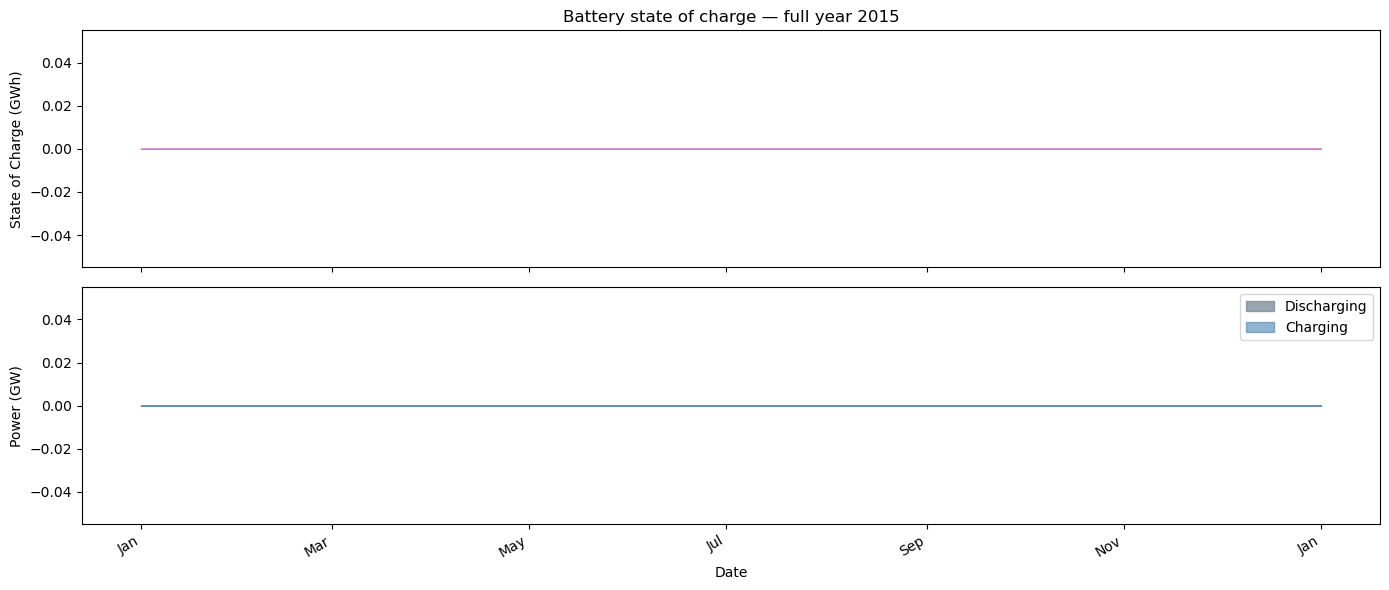

soc_full shape: (8760,) | non-zero hours: 0


In [125]:
# Full-year SoC and battery power
# strip_tz defined in the dispatch-week cell above
soc_full   = strip_tz(n.storage_units_t.state_of_charge["battery storage"])
bat_p_full = strip_tz(n.storage_units_t.p["battery storage"])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].fill_between(soc_full.index, soc_full.values / 1e3, color="purple", alpha=0.5)
axes[0].set_ylabel("State of Charge (GWh)")
axes[0].set_title("Battery state of charge — full year 2015")

axes[1].fill_between(bat_p_full.index,
                     bat_p_full.clip(lower=0).values / 1e3, 0,
                     color="slategray", alpha=0.7, label="Discharging")
axes[1].fill_between(bat_p_full.index, 0,
                     -bat_p_full.clip(upper=0).values / 1e3,
                     color="steelblue", alpha=0.6, label="Charging")
axes[1].set_ylabel("Power (GW)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("taskC_soc_full_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("soc_full shape:", soc_full.shape, "| non-zero hours:", (soc_full > 0).sum())


### C.7 — Duration curve

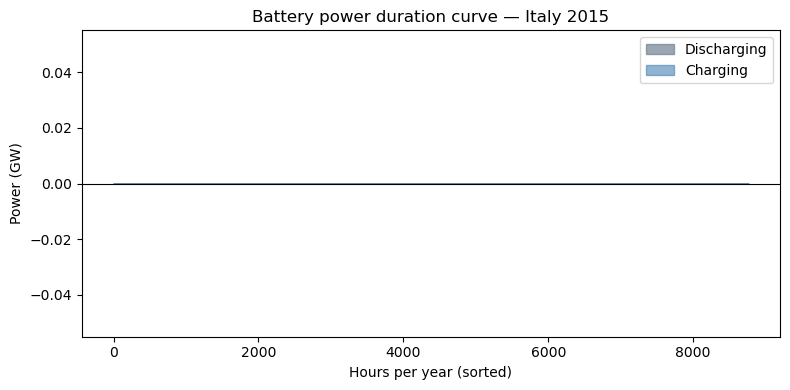

Max discharge: 0.000 GW | Max charge: -0.000 GW
Hours discharging: 0 | Hours charging: 0


In [126]:
# Duration curve — bat_p_full defined in cell above
fig, ax = plt.subplots(figsize=(8, 4))

discharge_vals       = bat_p_full.clip(lower=0).values / 1e3
charge_vals          = bat_p_full.clip(upper=0).values / 1e3  # negative

bat_sorted_discharge = np.sort(discharge_vals)[::-1]
bat_sorted_charge    = np.sort(charge_vals)   # ascending → most negative first

hours = np.arange(1, len(bat_sorted_discharge) + 1)

ax.fill_between(hours, 0, bat_sorted_discharge,
                color="slategray", alpha=0.7, label="Discharging")
ax.fill_between(hours, bat_sorted_charge, 0,
                color="steelblue", alpha=0.6, label="Charging")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Hours per year (sorted)")
ax.set_ylabel("Power (GW)")
ax.set_title("Battery power duration curve — Italy 2015")
ax.legend()
plt.tight_layout()
plt.savefig("taskC_battery_duration_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Max discharge: {:.3f} GW | Max charge: {:.3f} GW".format(
    bat_sorted_discharge[0], -bat_sorted_charge[0]))
print("Hours discharging: {} | Hours charging: {}".format(
    (bat_p_full > 0).sum(), (bat_p_full < 0).sum()))


### C.8 — Comparison

In [127]:
# Build model without battery
n_no_bat = pypsa.Network()
n_no_bat.set_snapshots(hours_in_2015.values)
n_no_bat.add("Bus", "ITA")
n_no_bat.add("Carrier", ["onwind", "solar", "OCGT", "CCGT"],
             color=["dodgerblue", "gold", "indianred", "yellowgreen"])
n_no_bat.add("Load", "demand", bus="ITA", p_set=data_el[country].values)
n_no_bat.add("Generator", "OCGT", bus="ITA", carrier="OCGT",
             capital_cost=costs.at["OCGT","capital_cost"],
             marginal_cost=costs.at["OCGT","marginal_cost"],
             efficiency=costs.at["OCGT","efficiency"],
             p_nom_extendable=True)
n_no_bat.add("Generator", "onwind", bus="ITA", carrier="onwind",
             p_max_pu=CF_wind.values,
             capital_cost=costs.at["onwind","capital_cost"],
             marginal_cost=costs.at["onwind","marginal_cost"],
             efficiency=costs.at["onwind","efficiency"],
             p_nom_extendable=True)
n_no_bat.add("Generator", "solar", bus="ITA", carrier="solar",
             p_max_pu=CF_solar.values,
             capital_cost=costs.at["solar","capital_cost"],
             marginal_cost=costs.at["solar","marginal_cost"],
             efficiency=costs.at["solar","efficiency"],
             p_nom_extendable=True)
n_no_bat.add("Generator", "CCGT", bus="ITA", carrier="CCGT",
             capital_cost=costs.at["CCGT","capital_cost"],
             marginal_cost=costs.at["CCGT","marginal_cost"],
             efficiency=costs.at["CCGT","efficiency"],
             p_nom=6000)

n_no_bat.optimize(solver_name="highs")
print("Objective without battery (B€/a):", round(n_no_bat.objective / 1e9, 3))


Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 330.74it/s]
INFO:linopy.io: Writing time: 0.12s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-vbwj2ij9 has 78843 rows; 35043 cols; 127199 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 6e+04]
Presolving model
30836 rows, 30839 cols, 74988 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
30836 rows, 30839 cols, 74988 nonzeros  0s
Presolve reductions: rows 30836(-48007); columns 30839(-4204); nonzeros 74988(-52211) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.14345e+08) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35043 primals, 78843 duals
Objective: 2.15e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      22568     2.1495305448e+10 Pr: 0(0) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-vbwj2ij9
Model status        : Optimal
Simplex   iterations: 22568
Objective value     :  2.1495305448e+10
P-D objective error :  2.6921672575e-13
HiGHS run time      :          0.63
Objective without battery (B€/a): 21.495


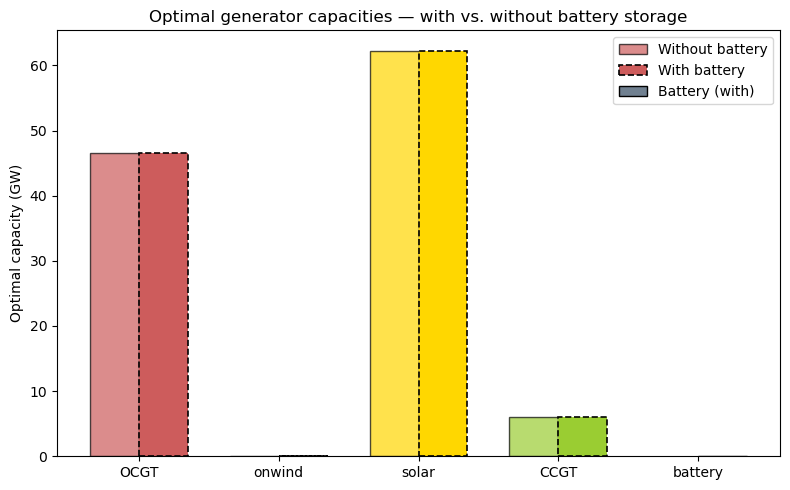


System cost WITHOUT battery: 21.495 B€/a
System cost WITH battery:    21.495 B€/a
Cost saving from storage:    0.000 B€/a


In [128]:
# Capacity comparison bar chart
labels = ["OCGT", "onwind", "solar", "CCGT"]

def get_cap(net):
    d = {}
    for g in labels:
        row = net.generators.loc[g]
        d[g] = row.p_nom_opt if row.p_nom_extendable else row.p_nom
    return pd.Series(d).div(1e3)

cap_bat    = get_cap(n)
cap_no_bat = get_cap(n_no_bat)

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, cap_no_bat, width, label="Without battery",
            color=["indianred","dodgerblue","gold","yellowgreen"], alpha=0.7, edgecolor="k")
b2 = ax.bar(x + width/2, cap_bat, width, label="With battery",
            color=["indianred","dodgerblue","gold","yellowgreen"], alpha=1.0, edgecolor="k",
            linewidth=1.2, linestyle="--")

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Optimal capacity (GW)")
ax.set_title("Optimal generator capacities — with vs. without battery storage")

# Add battery bar
bat_gw = n.storage_units.p_nom_opt["battery storage"] / 1e3
ax.bar(len(labels) + width/2, bat_gw, width, label="Battery (with)", color="slategray", edgecolor="k")
ax.set_xticks(list(range(len(labels))) + [len(labels)])
ax.set_xticklabels(labels + ["battery"])

ax.legend()
plt.tight_layout()
plt.savefig("taskC_capacity_comparison.png", dpi=150)
plt.show()

print("\nSystem cost WITHOUT battery: {:.3f} B€/a".format(n_no_bat.objective / 1e9))
print("System cost WITH battery:    {:.3f} B€/a".format(n.objective / 1e9))
print("Cost saving from storage:    {:.3f} B€/a".format(
    (n_no_bat.objective - n.objective) / 1e9))


### C.9 — Battery costs and revenue

In [129]:
# Battery market revenues
# strip_tz defined in the dispatch-week cell above
bat_p_signed = strip_tz(n.storage_units_t.p["battery storage"])
# marginal_price: squeeze to Series whether it's single-column DataFrame or already a Series
price_raw = n.buses_t.marginal_price
if isinstance(price_raw, pd.DataFrame):
    price = strip_tz(price_raw.squeeze() if price_raw.shape[1] == 1 else price_raw["ITA"])
else:
    price = strip_tz(price_raw)

# Align to be safe
bat_p_signed, price = bat_p_signed.align(price, join="inner")

discharge = bat_p_signed.clip(lower=0)
charge    = bat_p_signed.clip(upper=0).abs()

revenue_from_discharge = (discharge * price).sum() / 1e6
cost_of_charging       = (charge    * price).sum() / 1e6
bat_revenue_net        = revenue_from_discharge - cost_of_charging

bat_cost = (n.storage_units.p_nom_opt["battery storage"]
            * (costs.at["battery inverter", "capital_cost"]
               + 2 * costs.at["battery storage", "capital_cost"])
            / 1e6)

print(f"Revenue from discharging:  {revenue_from_discharge:.2f} M€/a")
print(f"Cost of charging:          {cost_of_charging:.2f} M€/a")
print(f"Net battery revenue:       {bat_revenue_net:.2f} M€/a")
print(f"Battery annualised cost:   {bat_cost:.2f} M€/a")
print(f"Ratio net/cost (≈ 1.0):   {bat_revenue_net/bat_cost:.4f}")


Revenue from discharging:  0.00 M€/a
Cost of charging:          0.00 M€/a
Net battery revenue:       0.00 M€/a
Battery annualised cost:   -0.00 M€/a
Ratio net/cost (≈ 1.0):   nan


/var/folders/4m/0vxd6phj50l_7jlbj12csnd40000gn/T/ipykernel_11918/2794477752.py:30: RuntimeWarning:

invalid value encountered in scalar divide



### C.10 — Intraday and seasonal storage analysis

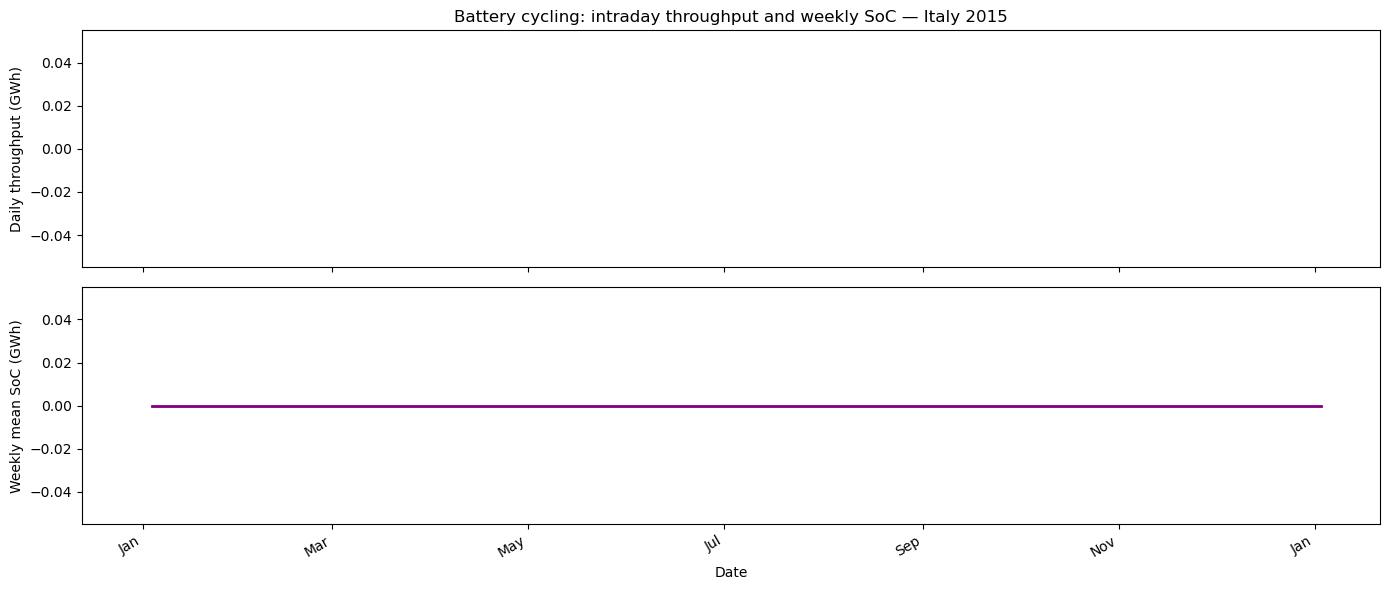

Battery power capacity:       -0.00 GW
Battery energy capacity:      -0.00 GWh
Total annual discharge:       0.00 TWh
Full equivalent cycles/year:  nan
Average daily throughput:     0.000 GWh/day


/var/folders/4m/0vxd6phj50l_7jlbj12csnd40000gn/T/ipykernel_11918/2295080027.py:31: RuntimeWarning:

invalid value encountered in scalar divide



In [130]:
# Intraday vs Seasonal analysis
# bat_p_full and soc_full are already tz-naive (defined in C.6 above)
bat_discharge_ts = bat_p_full.clip(lower=0)   # MW, hourly
bat_charge_ts    = bat_p_full.clip(upper=0).abs()

# resample: sum of hourly MW values = MWh per period
intraday_throughput = bat_discharge_ts.resample("D").sum() / 1e3   # GWh/day
soc_weekly          = soc_full.resample("W").mean() / 1e3          # GWh

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].bar(intraday_throughput.index, intraday_throughput.values,
            color="slategray", alpha=0.7, width=1)
axes[0].set_ylabel("Daily throughput (GWh)")
axes[0].set_title("Battery cycling: intraday throughput and weekly SoC — Italy 2015")

axes[1].plot(soc_weekly.index, soc_weekly.values, "purple", lw=2)
axes[1].fill_between(soc_weekly.index, 0, soc_weekly.values,
                     color="purple", alpha=0.3)
axes[1].set_ylabel("Weekly mean SoC (GWh)")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("taskC_intraday_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistics — bat_discharge_ts is in MW (hourly), sum = MWh
max_energy      = n.storage_units.p_nom_opt["battery storage"] * 2   # MWh
total_discharge = bat_discharge_ts.sum()                              # MWh
n_cycles        = total_discharge / max_energy
print(f"Battery power capacity:       {n.storage_units.p_nom_opt['battery storage']/1e3:.2f} GW")
print(f"Battery energy capacity:      {max_energy/1e3:.2f} GWh")
print(f"Total annual discharge:       {total_discharge/1e6:.2f} TWh")
print(f"Full equivalent cycles/year:  {n_cycles:.1f}")
print(f"Average daily throughput:     {total_discharge/365/1e3:.3f} GWh/day")
